---
title: "The ERA5 Spatial Aggregation Pipeline"
exec_all: true
---

<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
#| hide: null
from era5_sandbox.core import *

## era5_sandbox

> Sandbox environment for era5 development

This package documents the development and implementation of functions and code for the Madagascar ERA5 dataset project. The goal is for exposure data to be made available at the daily resolution when possible. Finer resolutions shouldn’t ever be needed for our purposes, and it should then be relatively easy to aggregate at coarser resolutions, such as weekly or monthly. Additionally, we've extended this work to Nepal as well.

Variables should generally be made available from 2010 onward, as that’s where our clinic data starts.

All data are ideally made available at the “healthshed” geographical level. Healthsheds are defined as geographical areas where people who live all go to the same clinic. There are a total of ~2700 public clinics in Madagascar, hence ~2700 healthsheds, with each healthshed containing ~10000 people on average.

Preliminary list of environmental variables

- [x] 2-m air temperature from ERA5: daily min, max, mean
 
- [x] 2-m air dew point temperature from ERA5: daily min, max, mean

- [x] Precipitation: daily total (ERA5)

- [x] Soil moisture: daily average (ERA5)

Variables from other sources:

- [ ] Sea surface temperature: daily average and maximum in the nearest neighbor for each healthshed.

- [ ] Precipitation: daily total (CHIRPS)

- [ ] Chlorophyll-A (Giacomo)

- [ ] Wealth index: Available from Giacomo 

- [ ] NDVI

- [ ] Tropical storm

- [ ] Flooding

- [ ] Deforestation

- [ ] Linking/segmenting healthsheds into climate zones and other 

- [ ] Relative humidity: daily average (lower priority)

Those from the ERA5 dataset will be housed here, but we may likely develop a separate repository for the other datasets.

## Developer Guide

This package is built and maintained with `nbdev`. If you are new to using `nbdev` here are some useful pointers to get you started.

### Install era5_sandbox in Development mode

```sh
# make sure era5_sandbox package is installed in development mode
$ pip install -e .
```

To make changes, go to the "notes" directory and edit the notebooks as necessary.
Each notebook refers to a module in the era5_sandbox package. Cells are exported to the module
when the notebook is saved and you run the following command:

```sh
$ nbdev_export
```

For e.g., to change functionality of the [`testAPI()`](https://TinasheMTapera.github.io/era5_sandbox/core.html#testapi) function in the testAPI Hydra rule, you would edit the [`testAPI`](https://TinasheMTapera.github.io/era5_sandbox/core.html#testapi) notebook in the `notes` directory `notes/testAPI.ipynb`, and then save that notebook and run `nbdev_export` to update the `core` module in the package.

### How to Run the Pipeline

The pipeline downloads ERA5 variables for a given date range and geographical bounding box. You can learn how each of these steps was by following the notebooks in `notes` in numerical order.

::: {.callout-important}
The pipeline has two implementations: one using `snakemake` and `hydra`, and another using `pytask`. The `pytask` implementation is the more recent one, and is recommended for future use. The `snakemake` implementation is left here for reference to legacy code.
:::

#### Using `pytask`

To run the pipeline, the `pytask` config at `note/20_pytask_config.qmd` should be reviewed
and updated if necessary. The pipeline can then be run with the following command:

```sh
$ sbatch pytask.sbatch
```

#### Using `snakemake` and `hydra`

To run the pipeline, the config at `config/config.yaml` should be updated with the desired date range and geographical bounding box. The pipeline can then be run with the following command:

```sh
sbatch snakemake.sbatch
```

### What Does the Pipeline Produce?

Using `pytask`'s data catalog, you can investigate the downloaded raw data with python, eg.:

In [ ]:
#| exec_doc: #
import xarray as xr
from era5_sandbox.config import data_catalog
from era5_sandbox.core import ClimateDataFileHandler

ex_nc = list(data_catalog['download']['outputs']._entries).pop()
ex_nc_path = data_catalog['download']['outputs'][ex_nc].load()

with ClimateDataFileHandler(ex_nc_path) as handler:
    ds = xr.open_dataset(handler.get_dataset("instant"))

ds

<xarray.Dataset> Size: 53MB
Dimensions:     (valid_time: 744, latitude: 49, longitude: 91)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 6kB 2024-03-01 ... 2024-03-31T23:...
  * latitude    (latitude) float64 392B 30.8 30.7 30.6 30.5 ... 26.2 26.1 26.0
  * longitude   (longitude) float64 728B 79.6 79.7 79.8 79.9 ... 88.4 88.5 88.6
    expver      (valid_time) <U4 12kB ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 13MB ...
    t2m         (valid_time, latitude, longitude) float32 13MB ...
    tp          (valid_time, latitude, longitude) float32 13MB ...
    swvl1       (valid_time, latitude, longitude) float32 13MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-09-16T20:55 GRIB to CDM+CF via cfgrib-0.9.1...

And plot it with cartopy, eg.:

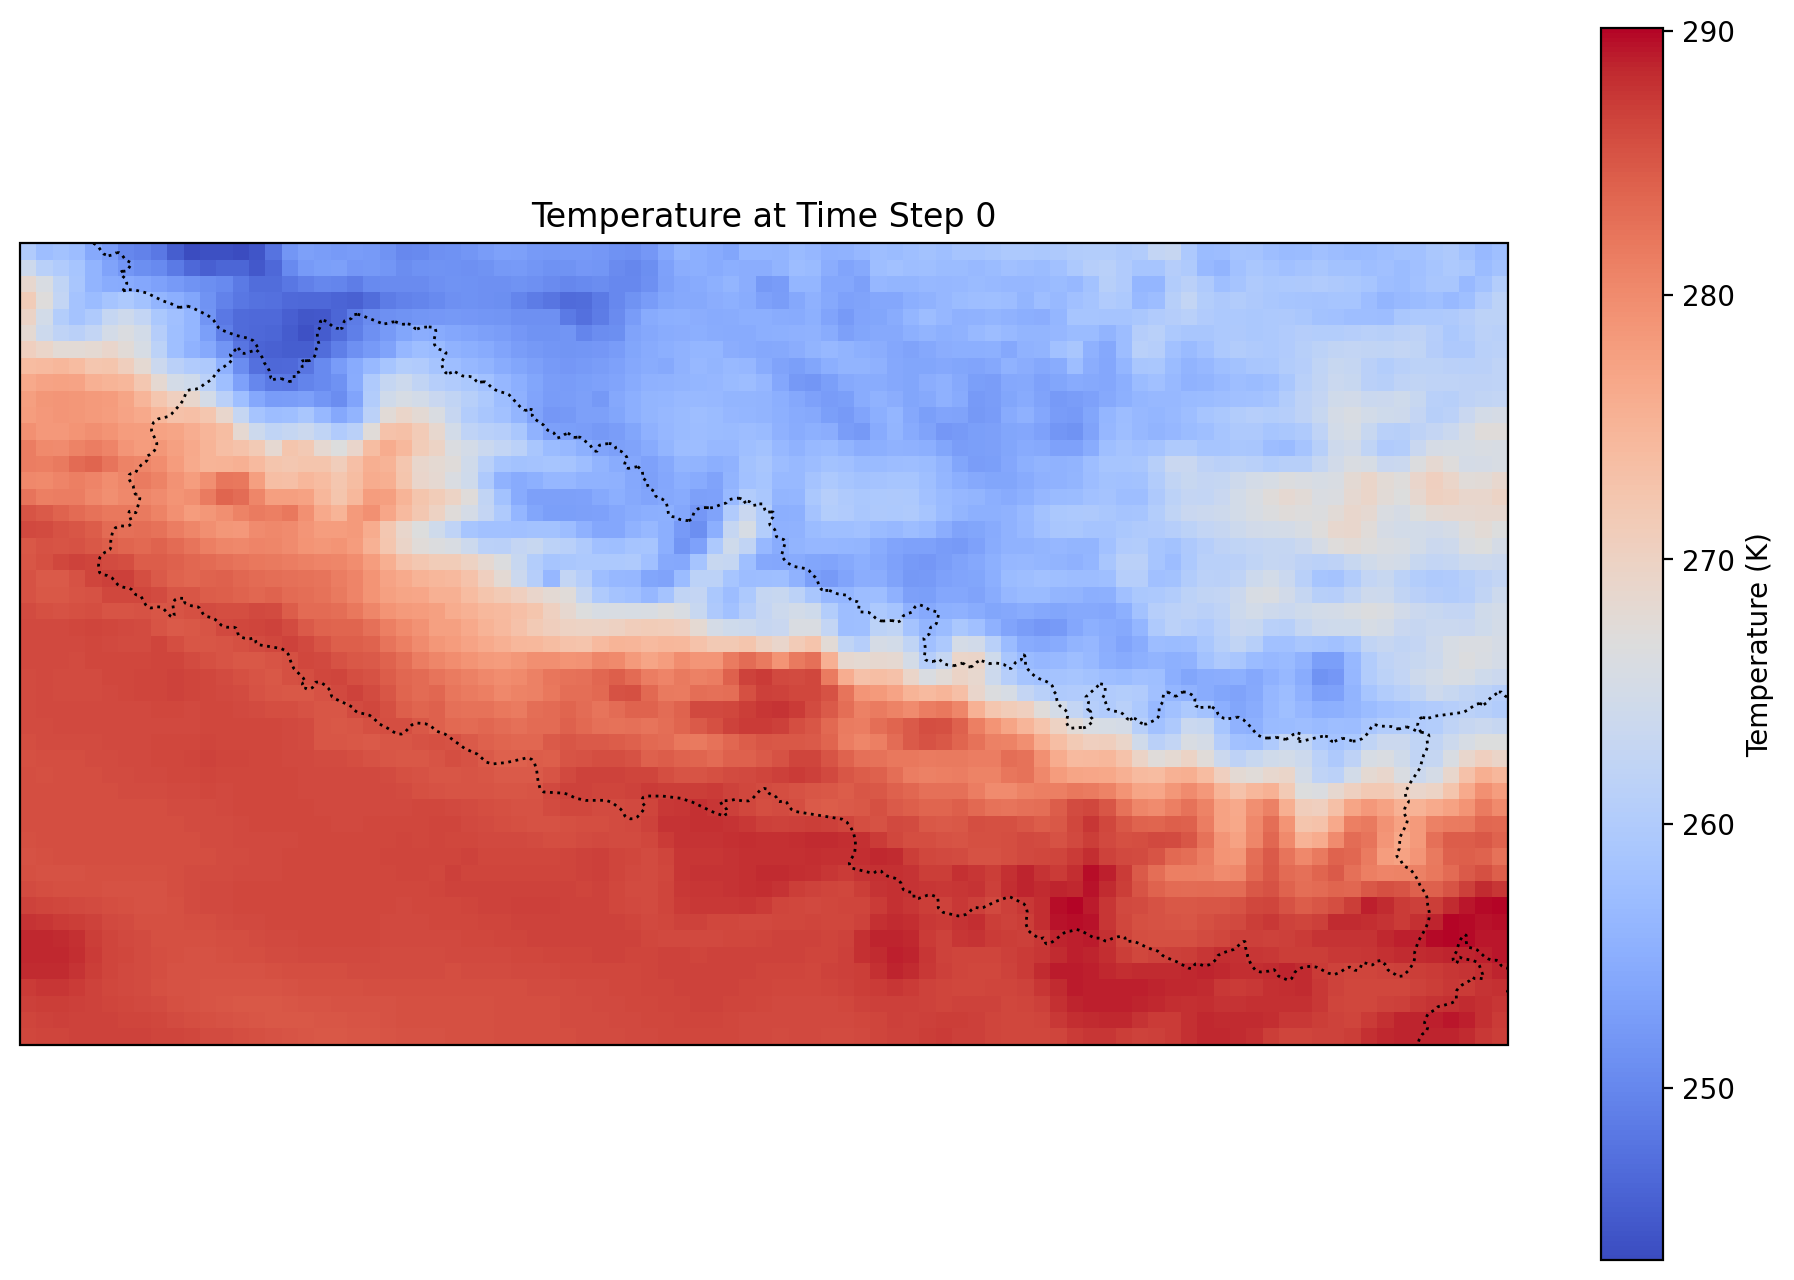

In [ ]:
#| exec_doc: #
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

temperature = ds["t2m"]

# Select a specific time step
temperature_at_time = temperature.isel(valid_time=0)

# Plot the data on a map
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
temperature_at_time.plot(ax=ax, cmap="coolwarm", transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Temperature (K)"})
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.set_title("Temperature at Time Step 0")
plt.show()

You can also load the aggregated data:

In [ ]:
#| exec_doc: #
import pandas as pd
import geopandas as gpd
from era5_sandbox.config import data_catalog

ex_agg_path = data_catalog['aggregate']['outputs']['2019_08_madagascar_night_d2m_max.parquet'].load()

gpd.read_parquet(ex_agg_path).describe()

,day_01,day_02,day_03,day_04,day_05,day_06,day_07,day_08,day_09,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31,day_32
count,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000,2701.000000
mean,290.493048,290.145274,288.953153,288.503714,288.439820,288.304426,286.940995,287.186512,287.453656,287.843029,288.301938,288.778014,288.813762,288.667253,288.796892,288.547945,288.197632,287.882440,287.659818,289.291587,289.911503,288.760939,288.257644,288.271450,287.746390,288.379399,288.504720,287.665699,288.149861,288.266861,288.644028,288.224829
std,2.616922,2.832083,3.215642,3.566019,4.401416,4.198817,5.235795,4.444031,4.346305,3.435444,2.735781,2.864494,2.841268,3.080593,3.306217,2.938165,3.018303,2.849850,2.817690,2.600946,2.584079,3.161855,3.171827,2.983778,3.223380,2.918867,2.844314,3.052635,3.077292,3.093706,3.335983,3.296264
min,284.295898,281.673340,280.566406,280.509521,277.348145,279.243164,274.955078,274.682129,275.397461,279.498291,282.339111,282.188721,282.470703,281.371582,280.724609,280.093506,280.849121,281.123535,281.952148,282.186768,284.168945,282.519287,282.015381,280.578857,281.183838,281.146973,281.977539,281.014648,280.787842,281.631348,281.349854,280.615967
25%,288.031494,287.739014,286.978271,285.750488,284.326904,284.071289,281.695068,283.710449,284.153076,285.459717,286.141846,286.444092,286.505859,286.104004,286.114014,286.730225,286.005371,285.420166,285.230713,287.408203,287.744873,286.101318,285.243652,285.488281,285.170166,285.876465,286.145508,285.243164,285.579346,285.322754,285.930908,285.565186
50%,290.674316,290.331543,288.916260,288.472168,289.635742,289.390381,288.382568,287.926758,288.173096,287.859375,287.797852,288.716064,288.806641,288.789307,289.210938,288.769287,288.085205,287.698975,287.252930,289.310547,289.878418,288.511719,288.420166,288.263916,287.717041,288.661621,288.999023,287.485107,288.326416,288.429199,288.576416,288.093018
75%,292.828369,292.707764,291.609375,291.655762,291.987305,291.845459,291.671631,291.051758,291.288574,291.000244,290.813721,291.365967,291.540039,291.393799,291.756592,291.094727,290.893311,290.266602,290.166748,291.649902,291.970459,291.342285,290.443848,290.660400,290.400146,290.360840,290.854004,290.328125,290.827881,290.999268,291.598877,291.072754
max,296.467285,295.717529,295.837158,295.693604,295.723389,296.195557,295.589600,295.345703,294.754639,294.483154,294.952148,294.815430,294.623779,295.088135,295.036621,294.847900,294.224609,294.522949,294.728760,295.268066,295.507324,295.797363,296.297119,296.222900,295.492432,295.406006,294.629883,295.211670,295.363037,295.263184,295.446533,295.408691
